## **Connect Colab**

In [1]:
#conect with drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ["GITHUB_TOKEN"] = "github"
os.environ["KAGGLE_USERNAME"] = "kaggle_username"
os.environ["KAGGLE_KEY"] = "kaggle_key"

In [3]:
!dir /content/drive/MyDrive/apai

fetch_src.sh  resnet50	setup_colab.sh


In [4]:
!sed -i 's/\r$//' /content/drive/MyDrive/apai/fetch_src.sh  # Windows users
!bash /content/drive/MyDrive/apai/fetch_src.sh

 fetch_src.sh — Download /src from GitHub

Checking environment...
GITHUB_TOKEN set
Fetching file list from GitHub API...
Found 15 file(s) under /src/
src/cl_strategies/ewc.py -> /content/src/cl_strategies/ewc.py
src/cl_strategies/naive.py -> /content/src/cl_strategies/naive.py
src/cl_strategies/reharsal.py -> /content/src/cl_strategies/reharsal.py
src/config/config.py -> /content/src/config/config.py
src/data/dataset.py -> /content/src/data/dataset.py
src/data/preprocessing.py -> /content/src/data/preprocessing.py
src/data/study_dataset.py -> /content/src/data/study_dataset.py
src/fine_tune/trainer.py -> /content/src/fine_tune/trainer.py
src/fine_tune/visualizer.py -> /content/src/fine_tune/visualizer.py
src/imports.py -> /content/src/imports.py
src/meta_learning/mamal.py -> /content/src/meta_learning/mamal.py
src/meta_learning/reptil.py -> /content/src/meta_learning/reptil.py
src/models/baselines.py -> /content/src/models/baselines.py
src/models/pretrained.py -> /content/src/models/p

## **Download DATASET**

In [5]:
!sed -i 's/\r$//' /content/drive/MyDrive/apai/setup_colab.sh  # Windows users
!bash /content/drive/MyDrive/apai/setup_colab.sh


UCF101 Project — Colab Setup Script

Checking environment...
KAGGLE_USERNAME set
KAGGLE_KEY set
config.py found

Installing kagglehub...
Done.

Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
Dataset path: /kaggle/input/ucf101-action-recognition

Detecting path and updating config.py...
Found in Kaggle input: /kaggle/input/ucf101-action-recognition/
DATASET_ROOT = '/kaggle/input/ucf101-action-recognition/'
OUTPUT_ROOT  = '/kaggle/working/ucf101-processed/'

Setup complete!
config.py updated on Drive.
Restarting kernel in 5 seconds...
Dataset cache stays on disk.
Run Cell 3 after restart to verify.
Restarting in 5...
Restarting in 4...
Restarting in 3...
Restarting in 2...
Restarting in 1...


In [6]:
# imports
%run /content/src/imports.py
criterion = nn.CrossEntropyLoss()

Using device: cuda


## **Preprocess the data**

In [ ]:
# Base 
cfg.OUTPUT_ROOT = "./UCF101/processed_data_base"
preprocess_dataset(splits=["train", "test"], target_classes=cfg.SELECTED_CLASSES)

# TASK 1
cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task1"
preprocess_dataset(splits=["train", "val", "test"], target_classes=cfg.TASK_1)




--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : ./UCF101/processed_data_task1
Classes: 3 | Limit: Full

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: ./UCF101/processed_data_task1

--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : ./UCF101/processed_data_task2
Classes: 3 | Limit: Full

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: ./UCF101/processed_data_task2


In [9]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1

class_to_idx = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}

print(f"\nclass_to_idx:\n{class_to_idx}")


class_to_idx:
{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12}


## **Create Loaders**

In [33]:
base_train = UCF101Clips(os.path.join(cfg.BASE_ROOT, "train"), class_to_idx=class_to_idx)
base_train_loader = DataLoader(base_train, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2)

base_test        = UCF101Clips(os.path.join(cfg.BASE_ROOT, "test"), class_to_idx=class_to_idx)
base_test_loader = DataLoader(base_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

task1_train = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx)
task1_val   = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "val"),   class_to_idx=class_to_idx)
task1_test  = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "test"),  class_to_idx=class_to_idx)

task1_train_loader = DataLoader(task1_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task1_val_loader   = DataLoader(task1_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_test_loader  = DataLoader(task1_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

combined_test        = ConcatDataset([base_test, task1_test])
combined_test_loader = DataLoader(combined_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

## **Upload Model**

In [34]:
model_base = ResNet50LSTM(num_classes = len(cfg.SELECTED_CLASSES)).to(device)
state      = torch.load(cfg.RESNET50_PATH, map_location=device)
model_base.load_state_dict(state)

<All keys matched successfully>

In [35]:
# new_num_classes=len(ALL_CLASSES_LIST)
model_task1 = expand_classifier(model_base, new_num_classes=len(ALL_CLASSES_LIST))

In [ ]:
results_baseline = evaluate_all_tasks(
    model            = model_task1,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader],
    combined_loaders = [combined_test_loader],
)

  base             -> Acc=0.9766  Loss=0.1630
  task1_only       -> Acc=0.0000  Loss=3.3487
  combined_t1      -> Acc=0.7455  Loss=0.9167


## **Task One**

In [13]:
test_acc_task_1, all_preds_task_1, all_labels_task_1 = test_model(model_task1, combined_test_loader)

Running Inference on Test Set...


Test Accuracy: 0.7455


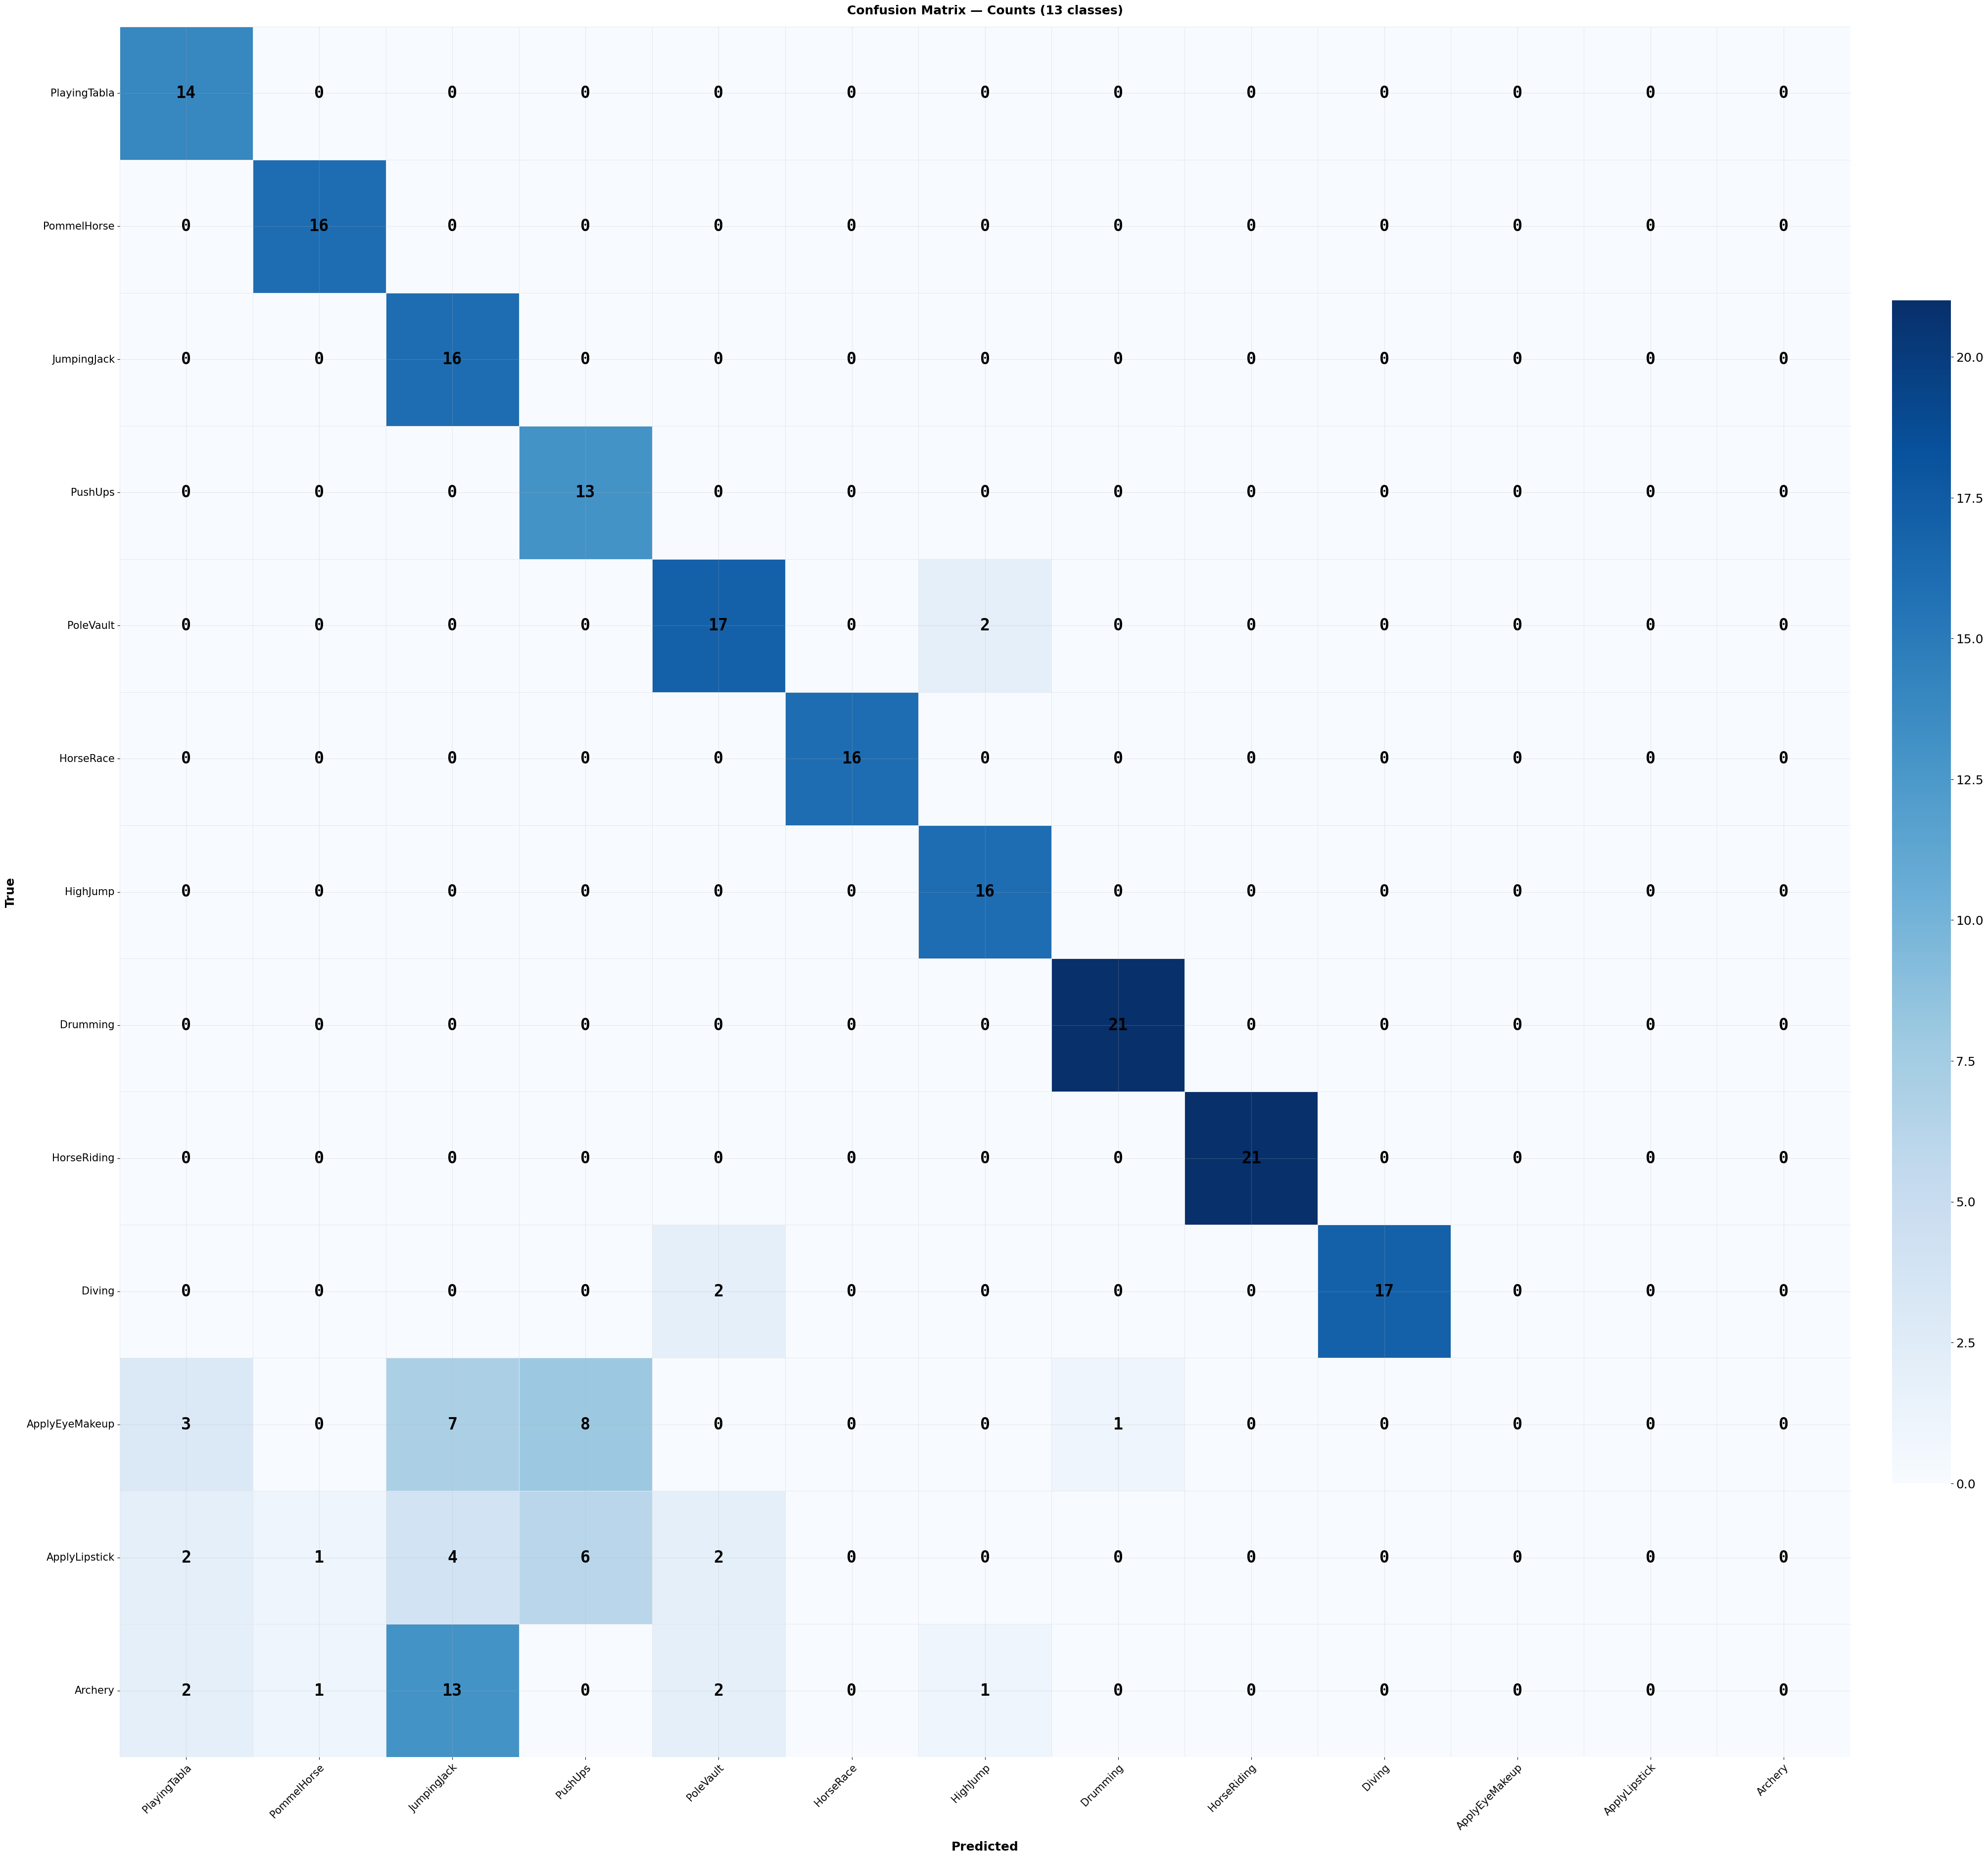

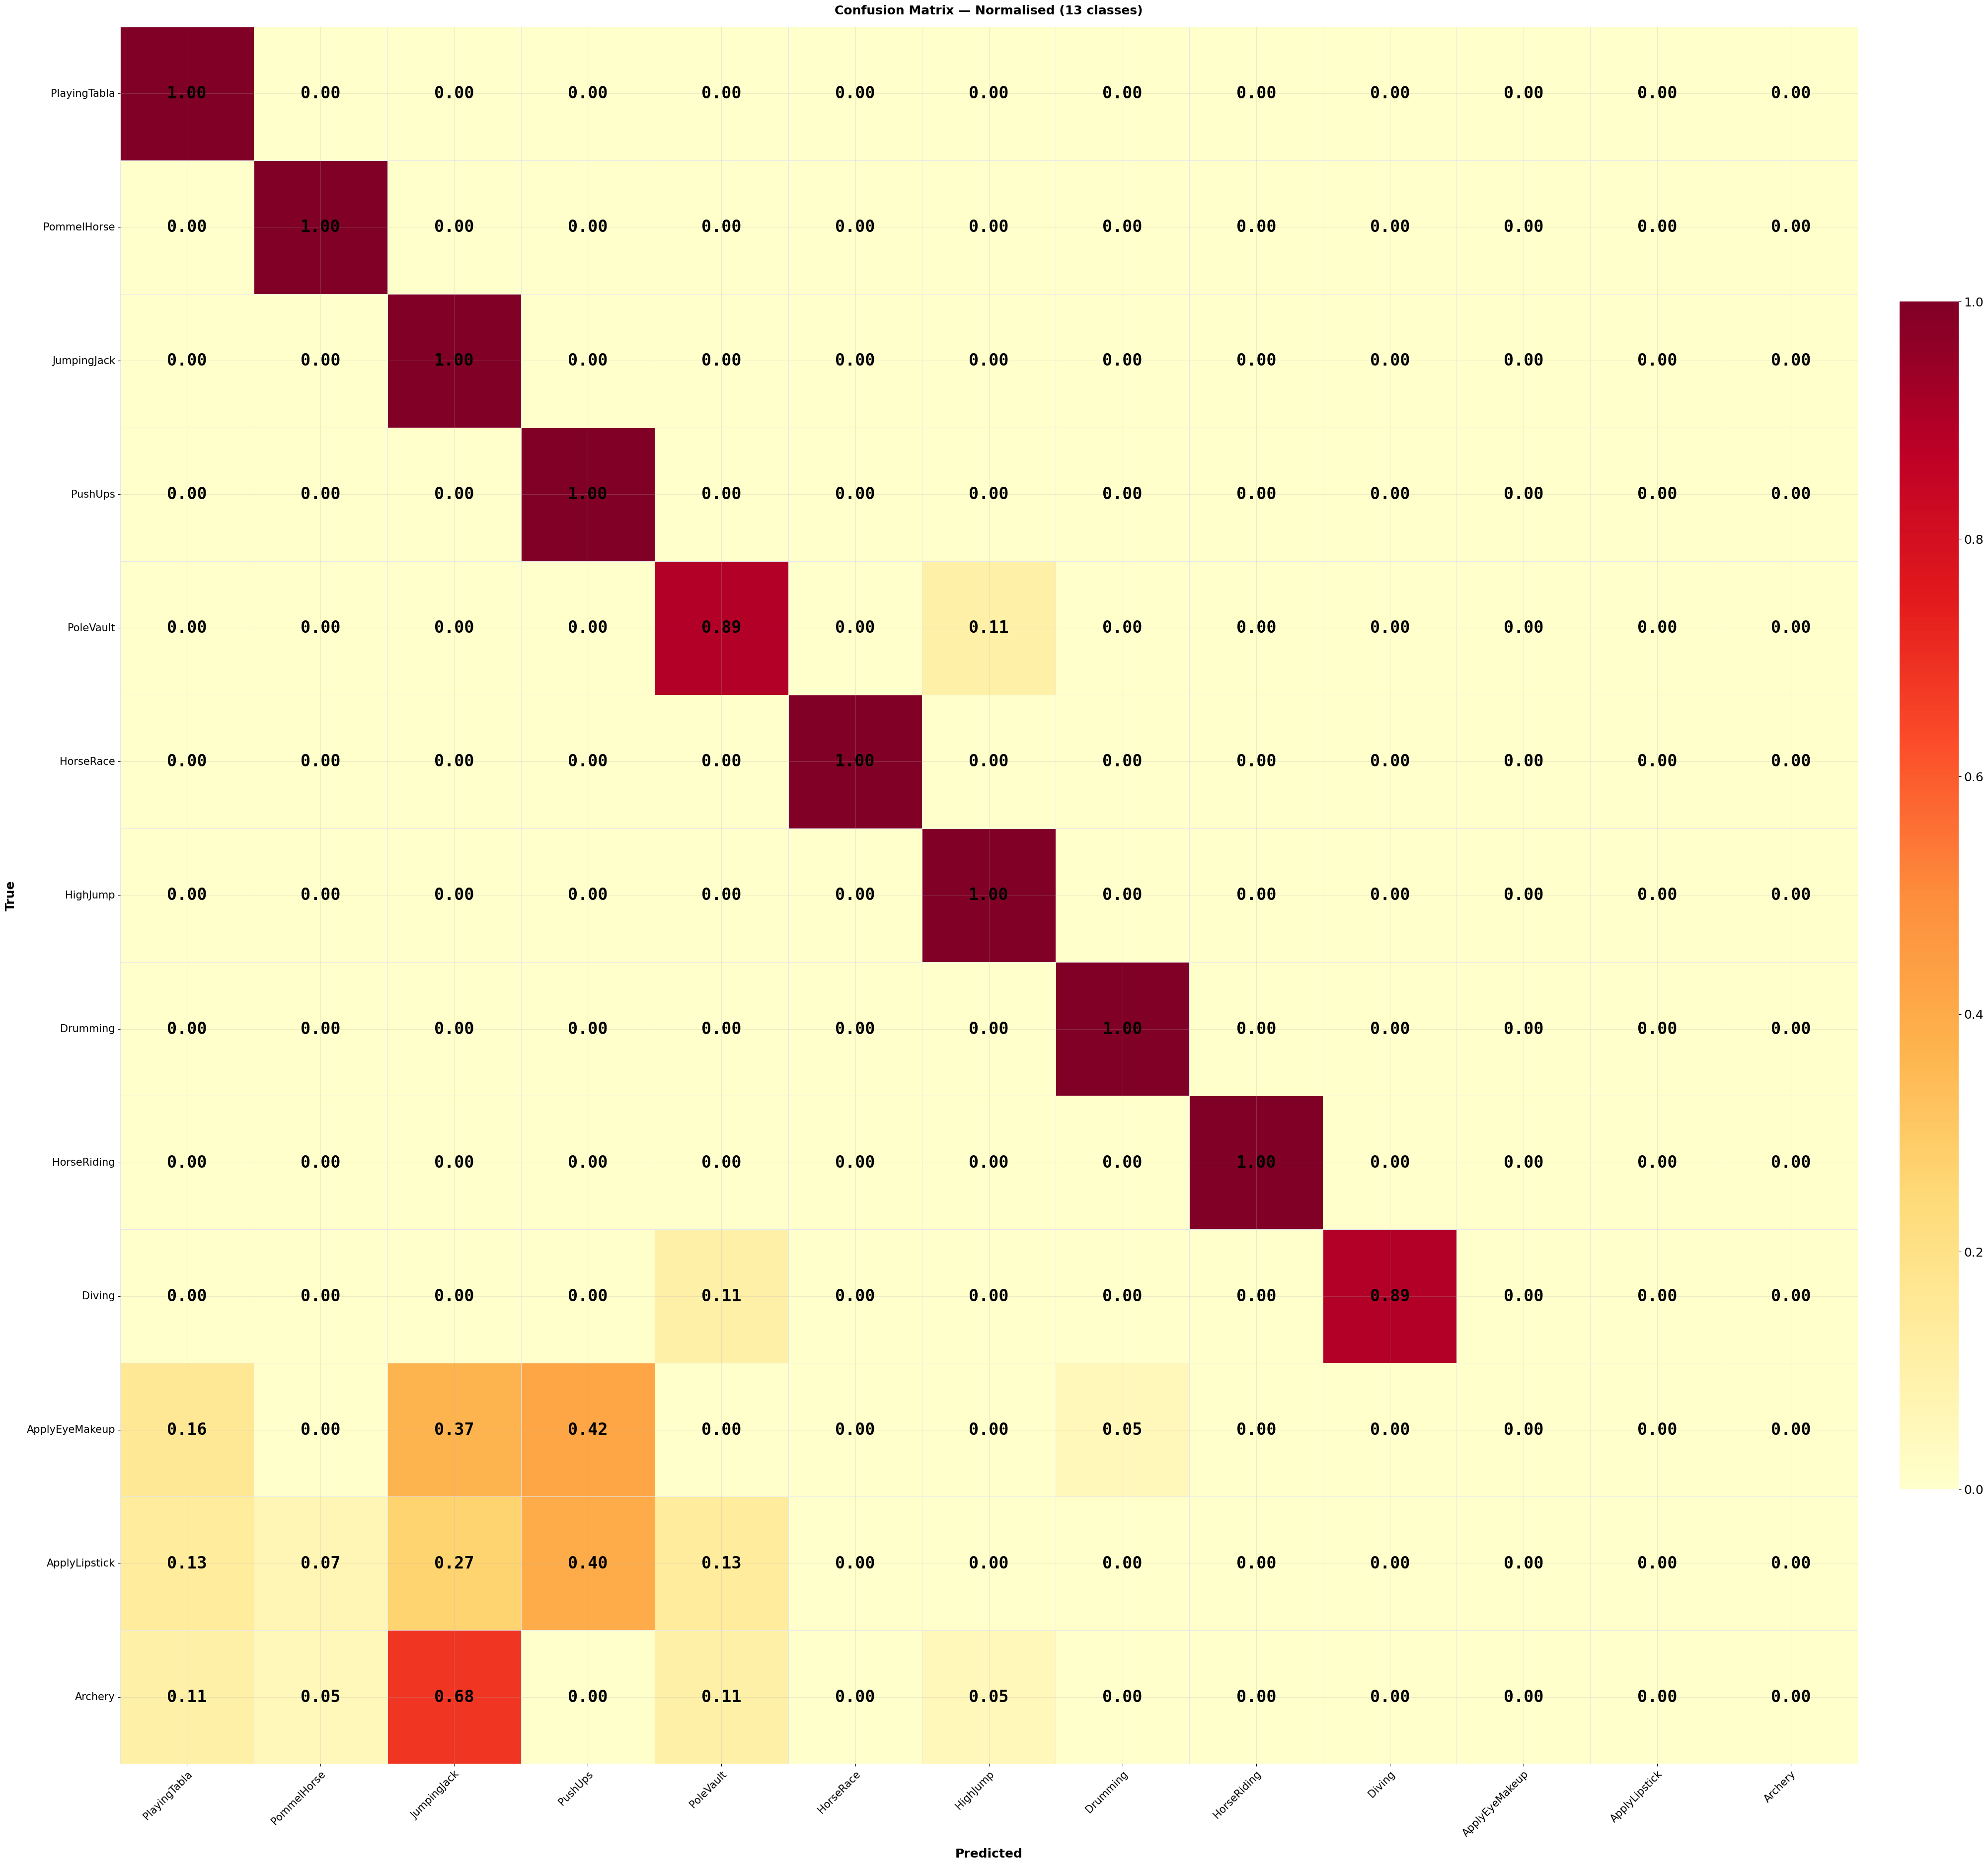

In [ ]:
# plot cm
print("Confusion matrix on combined tasks before training")
plot_confusion_matrix(all_labels_task_1, all_preds_task_1, num_classes=len(ALL_CLASSES_LIST), classes_list=ALL_CLASSES_LIST)

In [37]:
theta_opt = theta_star(model_base)

In [42]:
fisher_mat = getFisherDiagonal(base_train_loader, model_base, fishermax=1e6, device='cuda')

Computing Fisher: 100%|██████████| 125/125 [01:20<00:00,  1.55it/s]


In [ ]:
ewc_train_results = train_cl_EWC(model=model_task1, new_task_train_loader=task1_train_loader, 
        new_task_val_loader=task1_val_loader, old_task_val_loader=base_test_loader, 
        num_epochs=5, lr=1e-5, theta_star=theta_opt, fisher=fisher_mat)

Epoch 1/5 - Training: 100%|██████████| 38/38 [00:28<00:00,  1.33it/s]


Epoch 1/5 - Train Loss: 2.9711, Train Accuracy: 0.0000


Epoch 1/5 - Validation: 100%|██████████| 7/7 [00:03<00:00,  1.82it/s]


Epoch 1/5 - Val Loss: 2.5975, Val Accuracy: 0.0000


Epoch 1/5 - Old Task Validation: 100%|██████████| 22/22 [00:11<00:00,  1.94it/s]


...

Epoch 5/5 - Train Loss: 0.9445, Train Accuracy: 0.8671


Epoch 5/5 - Validation: 100%|██████████| 7/7 [00:03<00:00,  2.14it/s]


Epoch 5/5 - Val Loss: 0.9586, Val Accuracy: 0.8600


Epoch 5/5 - Old Task Validation: 100%|██████████| 22/22 [00:10<00:00,  2.03it/s]

Epoch 5/5 - Old Task Val Loss: 18.8340, Old Task Val Accuracy: 0.8070


In [ ]:
plot_training_results(ewc_train_results)

In [49]:
results_baseline = evaluate_all_tasks(
    model            = model_task1,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader],
    combined_loaders = [combined_test_loader],
)

  base             -> Acc=0.8070  Loss=0.8394
  task1_only       -> Acc=0.8491  Loss=0.9680
  combined_t1      -> Acc=0.8170  Loss=0.8699


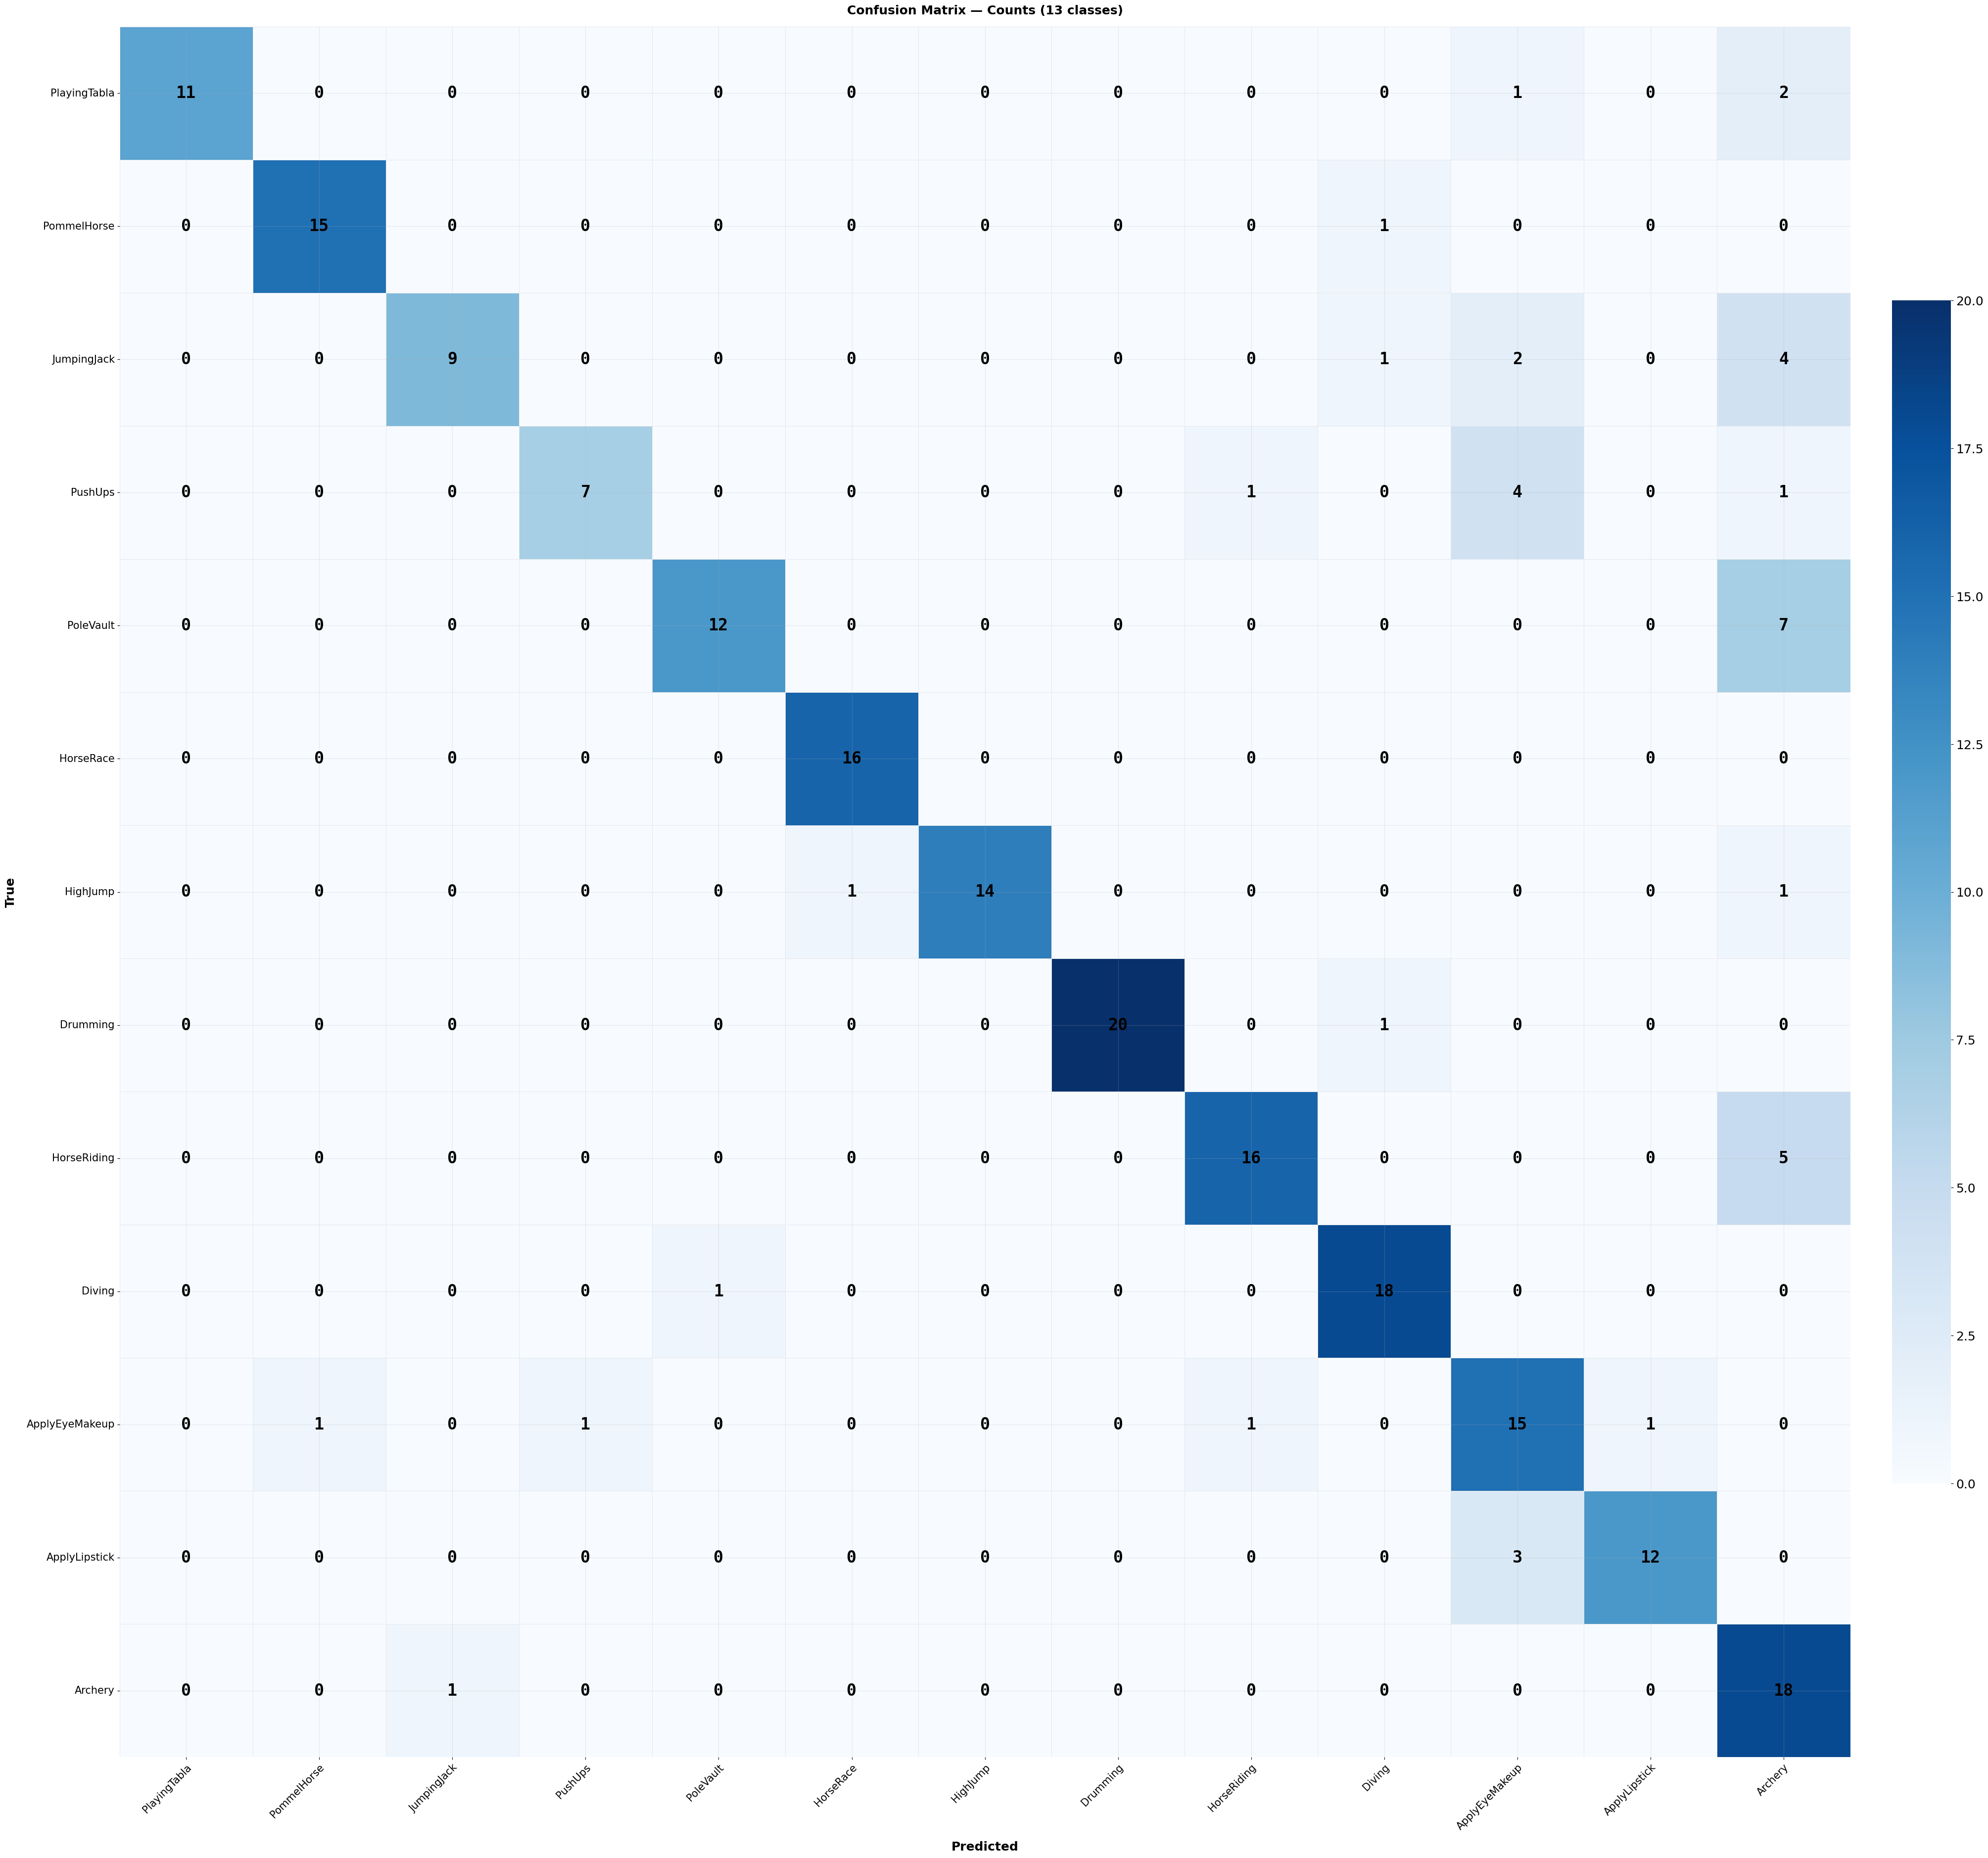

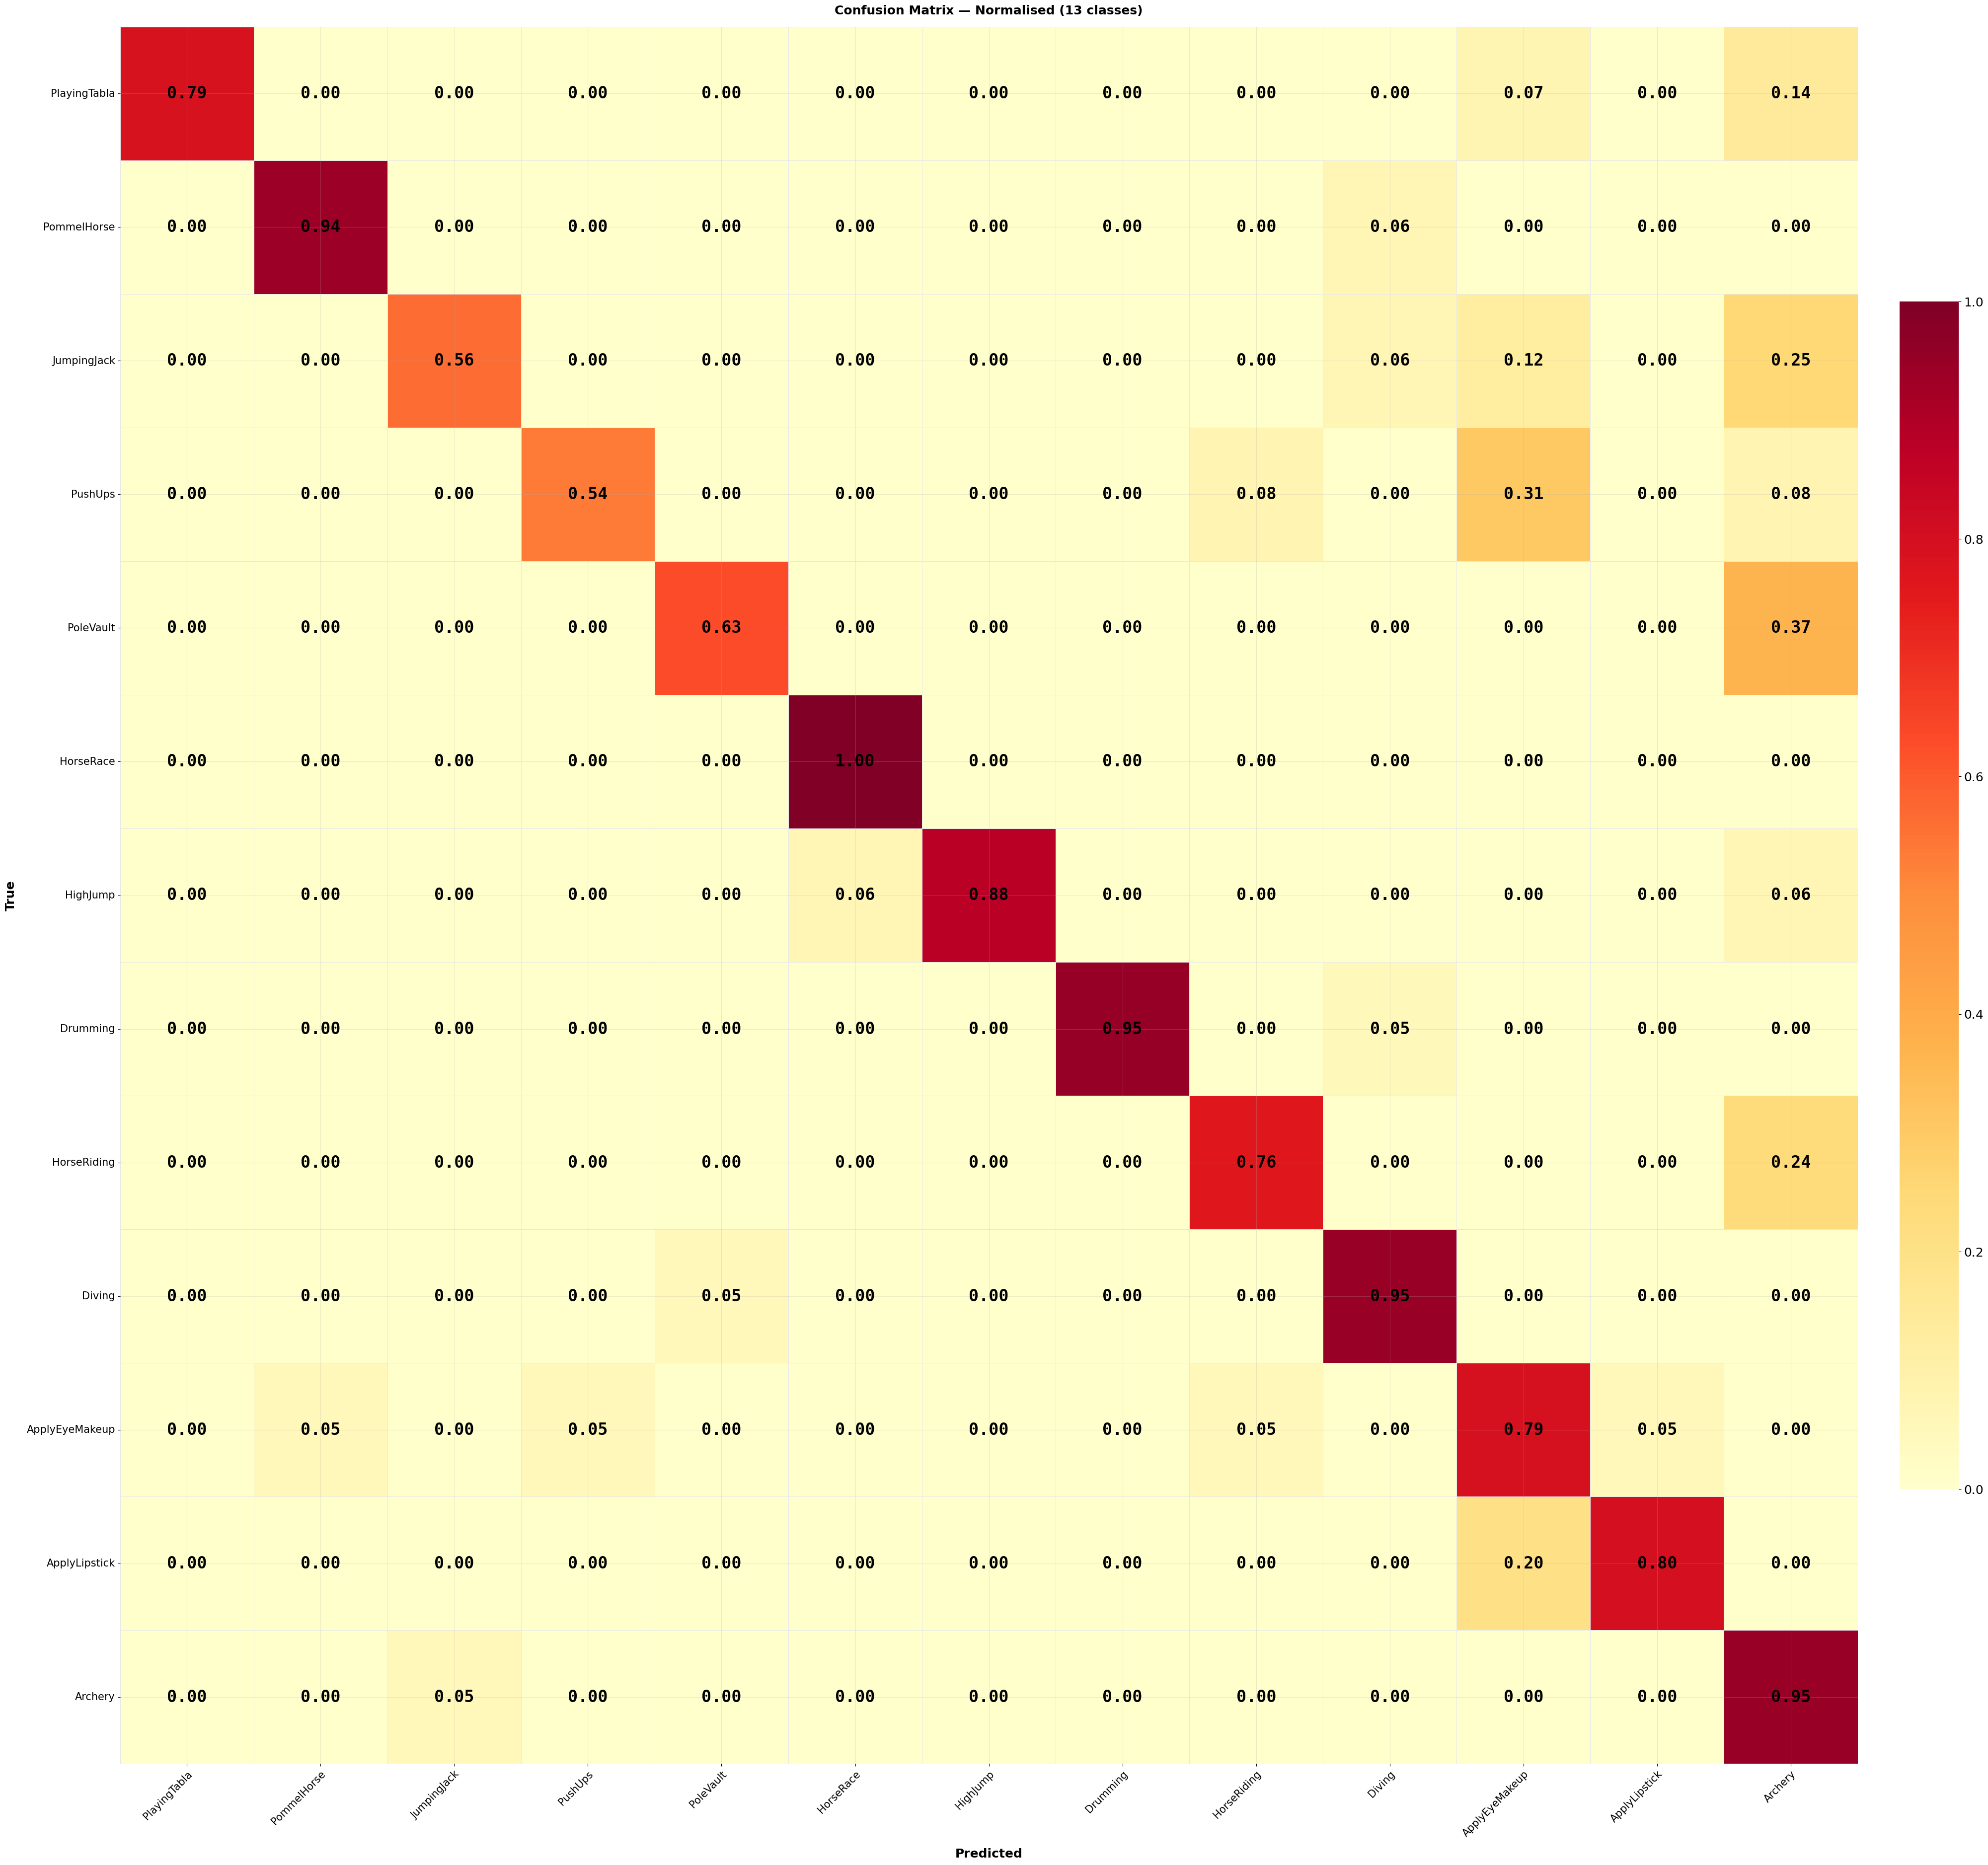

In [ ]:
# plot cm
print("COnfusion matrix on combined tasks after training")
plot_confusion_matrix(all_labels_task_1, all_preds_task_1, num_classes=len(ALL_CLASSES_LIST), classes_list=ALL_CLASSES_LIST)